# Tendu Leaf Supply Chain Analytics

## Python Analysis

### Project Context

This project explores the supply chain and business operations of a tendu leaf procurement and trading business. The overall project covers procurement, quality inspection, inventory, transportation, sales, expenses, buyers, and profitability, while this Python analysis focuses on selected areas requiring statistical exploration, EDA, relationship analysis, outlier detection, and visualisation.

The project was developed as a business analytics prototype inspired by a real-world business context. The dataset is structured for analytical purposes and is not presented as live operational business data.

### Business Problem

Tendu leaf businesses operate across multiple stages, from forest-level procurement and quality inspection to storage, transportation, sales, and payment collection. Analysing these activities together can help identify operational patterns, variability, profitability trends, and areas requiring managerial attention.

The objective is to transform operational data into meaningful business insights that can support better planning and decision-making.

### Objectives

- Analyse procurement and sales patterns over time
- Examine the distribution and variability of key business metrics
- Understand revenue, expense, and profitability patterns
- Explore buyer revenue concentration
- Analyse quality-related patterns and unusual observations
- Identify meaningful relationships between operational and financial variables
- Detect potential outliers in key numerical measures
- Develop clear visualisations to communicate analytical findings
- Prepare relevant analytical data for Power BI reporting

### Analytical Approach

Python is used to extend the earlier Excel and SQL analysis by focusing on:

- Statistical analysis
- Exploratory Data Analysis (EDA)
- Distributions and variability
- Relationship and correlation analysis
- Outlier identification
- Data visualisation
- Business interpretation of analytical findings

The Python analysis is designed to complement, rather than duplicate, the project's SQL analysis.

### Tools & Technologies

- **Python**
- **Pandas** – data manipulation and analysis
- **Matplotlib** – data visualisation
- **PostgreSQL** – data storage and querying
- **Jupyter Notebook** – Python analysis environment
- **Power BI** – business intelligence and dashboard reporting

### Project Workflow

**Excel Dataset → PostgreSQL Database → SQL Analysis → Python Analysis → Power BI**

Python acts as the analytical layer for statistical exploration, EDA, relationships, outlier analysis, and visualisation before the final insights are presented through Power BI.

### Expected Outcome

The analysis aims to identify meaningful patterns and relationships within procurement, sales, quality, expenses, and profitability data and translate these findings into practical business implications.

All conclusions are based on the patterns observed in the dataset and are presented without assuming causation where the data only indicates an association.

## 1. Python Setup & PostgreSQL Connection

The Python environment is connected to the PostgreSQL database used for the Tendu Leaf Supply Chain Analytics project. This allows the analysis to work directly with the structured relational data prepared during the SQL stage.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
import getpass

In [17]:

password = getpass.getpass("Enter PostgreSQL password: ")

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="tendu_supply_chain",
    user="postgres",
    password=password
)

print("PostgreSQL database connected successfully.")

Enter PostgreSQL password:  ········


PostgreSQL database connected successfully.


## 2. Data Loading & Initial Inspection

The required datasets are loaded from PostgreSQL into Python using pandas. Initial inspection is performed to understand the structure, size, data types, and key fields of the analytical datasets before further analysis.

In [19]:
# Load the sales data from PostgreSQL

sales = pd.read_sql("""
SELECT *
FROM sales;
""", conn)

sales.head()

/var/folders/gp/1z1_w1pd5fd_k80lhxcgxvjr0000gp/T/ipykernel_20271/2523222181.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales = pd.read_sql("""


,sale_id,buyer_id,bundle_id,leaf_grade,warehouse_id,transport_id,sale_date,quantity_sold_kg,selling_price_per_kg,total_sale_value,invoice_number
0,SAL001,BUY017,BUN001,Grade A,WH001,TR001,2025-06-11,21,259.0,5439.0,INVN001
1,SAL002,BUY042,BUN002,Grade A,WH003,TR002,2025-06-05,23,270.0,6210.0,INVN002
2,SAL003,BUY005,BUN003,Grade B,WH002,TR003,2025-05-23,16,238.0,3808.0,INVN003
3,SAL004,BUY031,BUN004,Grade B,WH005,TR004,2025-05-13,23,218.0,5014.0,INVN004
4,SAL005,BUY024,BUN005,Grade A,WH004,TR005,2025-06-20,19,293.0,5567.0,INVN005


In [20]:
sales.shape

(510, 11)

In [21]:
# Check column names and data types
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sale_id               510 non-null    str    
 1   buyer_id              510 non-null    str    
 2   bundle_id             510 non-null    str    
 3   leaf_grade            510 non-null    str    
 4   warehouse_id          510 non-null    str    
 5   transport_id          510 non-null    str    
 6   sale_date             510 non-null    object 
 7   quantity_sold_kg      510 non-null    int64  
 8   selling_price_per_kg  510 non-null    float64
 9   total_sale_value      510 non-null    float64
 10  invoice_number        510 non-null    str    
dtypes: float64(2), int64(1), object(1), str(7)
memory usage: 44.0+ KB


## 3. Data Quality & Statistical Analysis

The analytical datasets are checked for missing values, duplicate records, appropriate data types, and basic numerical validity. Descriptive statistics are then used to understand the central tendency and variability of key business measures.

In [22]:
# Check for missing values
sales.isnull().sum()

sale_id                 0
buyer_id                0
bundle_id               0
leaf_grade              0
warehouse_id            0
transport_id            0
sale_date               0
quantity_sold_kg        0
selling_price_per_kg    0
total_sale_value        0
invoice_number          0
dtype: int64

In [23]:
# Check for duplicate records
sales.duplicated().sum()

np.int64(0)

In [24]:
# Validate date and numerical fields

sales["sale_date"] = pd.to_datetime(sales["sale_date"])

print("Date range:", sales["sale_date"].min(), "to", sales["sale_date"].max())
print("\nNumerical field summary:")
print(sales[["quantity_sold_kg", "selling_price_per_kg", "total_sale_value"]].describe())

Date range: 2025-05-09 00:00:00 to 2026-07-02 00:00:00

Numerical field summary:
       quantity_sold_kg  selling_price_per_kg  total_sale_value
count        510.000000            510.000000        510.000000
mean          20.009804            248.574510       4971.856863
std            2.290731             34.234849        885.493341
min           16.000000            150.000000       2652.000000
25%           18.000000            221.000000       4369.250000
50%           20.000000            254.000000       4881.500000
75%           22.000000            276.000000       5628.000000
max           24.000000            300.000000       7200.000000


In [27]:
# Compare mean, median and variability

statistics = pd.DataFrame({
    "Mean": sales[[
        "quantity_sold_kg",
        "selling_price_per_kg",
        "total_sale_value"
    ]].mean(),
    "Median": sales[[
        "quantity_sold_kg",
        "selling_price_per_kg",
        "total_sale_value"
    ]].median(),
    "Std_Dev": sales[[
        "quantity_sold_kg",
        "selling_price_per_kg",
        "total_sale_value"
    ]].std()})
statistics


,Mean,Median,Std_Dev
quantity_sold_kg,20.009804,20.0,2.290731
selling_price_per_kg,248.574510,254.0,34.234849
total_sale_value,4971.856863,4881.5,885.493341


In [28]:
# Calculate key quartiles and percentiles

sales[[
    "quantity_sold_kg",
    "selling_price_per_kg",
    "total_sale_value"
]].quantile([0.25, 0.50, 0.75])

,quantity_sold_kg,selling_price_per_kg,total_sale_value
0.25,18.0,221.0,4369.25
0.50,20.0,254.0,4881.50
0.75,22.0,276.0,5628.00


## 4. Exploratory Data Analysis

Exploratory analysis is performed to identify patterns and variations in procurement, sales, expenses, buyer revenue, and leaf quality. The analysis focuses on business-relevant patterns rather than repeating the detailed SQL analysis.

In [31]:
# Load collection data for procurement EDA

collection = pd.read_sql("""
SELECT
    collection_date,
    collected_quantity_kg
FROM collection;
""", conn)

collection.head()


/var/folders/gp/1z1_w1pd5fd_k80lhxcgxvjr0000gp/T/ipykernel_20271/556049422.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  collection = pd.read_sql("""


,collection_date,collected_quantity_kg
0,2025-06-06,52
1,2025-05-29,45
2,2025-05-08,30
3,2025-05-10,57
4,2025-06-11,31


In [32]:
# Monthly procurement analysis

collection["collection_date"] = pd.to_datetime(collection["collection_date"])
monthly_procurement = (collection
    .groupby(collection["collection_date"].dt.to_period("M"))["collected_quantity_kg"]
    .sum()
    .reset_index())
monthly_procurement["collection_date"] = monthly_procurement["collection_date"].dt.to_timestamp()
monthly_procurement

,collection_date,collected_quantity_kg
0,2025-05-01,6909
1,2025-06-01,3327
2,2026-05-01,7279
3,2026-06-01,3695


In [33]:
# Measure monthly procurement variability

monthly_procurement["collected_quantity_kg"].describe()

count       4.000000
mean     5302.500000
std      2079.587379
min      3327.000000
25%      3603.000000
50%      5302.000000
75%      7001.500000
max      7279.000000
Name: collected_quantity_kg, dtype: float64

In [58]:
# Prepare monthly revenue and expense data

sales["sale_date"] = pd.to_datetime(sales["sale_date"])

monthly_revenue = (
    sales
    .groupby(sales["sale_date"].dt.to_period("M"))["total_sale_value"]
    .sum()
    .reset_index())

monthly_revenue["sale_date"] = monthly_revenue["sale_date"].dt.to_timestamp()


expenses = pd.read_sql("""
SELECT
    expense_date,
    amount_inr
FROM expenses;
""", conn)

expenses["expense_date"] = pd.to_datetime(expenses["expense_date"])

monthly_expenses = (
    expenses
    .groupby(expenses["expense_date"].dt.to_period("M"))["amount_inr"]
    .sum()
    .reset_index())

monthly_expenses["expense_date"] = monthly_expenses["expense_date"].dt.to_timestamp()


monthly_financials = pd.merge(
    monthly_revenue,
    monthly_expenses,
    left_on="sale_date",
    right_on="expense_date",
    how="outer")

monthly_financials = monthly_financials.fillna(0)

monthly_financials["operating_surplus"] = (
    monthly_financials["total_sale_value"]
    - monthly_financials["amount_inr"])

monthly_financials

/var/folders/gp/1z1_w1pd5fd_k80lhxcgxvjr0000gp/T/ipykernel_20271/3647782675.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  expenses = pd.read_sql("""


,sale_date,total_sale_value,expense_date,amount_inr,operating_surplus
0,2025-05-01,522683.0,2025-05-01 00:00:00,13695150.0,-13172467.0
1,2025-06-01,714716.0,2025-06-01 00:00:00,8367430.0,-7652714.0
2,2026-05-01,543699.0,2026-05-01 00:00:00,1485462.0,-941763.0
3,2026-06-01,739483.0,2026-06-01 00:00:00,699861.0,39622.0
4,2026-07-01,15066.0,0,0.0,15066.0


In [63]:
# Measure revenue and operating surplus variability

monthly_financials[
    ["total_sale_value", "operating_surplus"]
].describe()

,total_sale_value,operating_surplus
count,5.000000,5.000000e+00
mean,507129.400000,-4.342451e+06
std,291884.408486,5.888171e+06
min,15066.000000,-1.317247e+07
25%,522683.000000,-7.652714e+06
50%,543699.000000,-9.417630e+05
75%,714716.000000,1.506600e+04
max,739483.000000,3.962200e+04


In [36]:
# Analyse buyer revenue concentration

buyer_revenue = (
    sales
    .groupby("buyer_id")["total_sale_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index())

buyer_revenue["revenue_share_%"] = (
    buyer_revenue["total_sale_value"]
    / buyer_revenue["total_sale_value"].sum()
    * 100)

buyer_revenue["cumulative_share_%"] = (
    buyer_revenue["revenue_share_%"].cumsum())

buyer_revenue.head(10)

,buyer_id,total_sale_value,revenue_share_%,cumulative_share_%
0,BUY017,87999.0,3.470475,3.470475
1,BUY012,86252.0,3.401578,6.872053
2,BUY026,83326.0,3.286183,10.158236
3,BUY031,81957.0,3.232193,13.390429
4,BUY024,81935.0,3.231325,16.621754
5,BUY042,80872.0,3.189403,19.811157
6,BUY049,79863.0,3.149610,22.960767
7,BUY005,78064.0,3.078662,26.039429
8,BUY003,76306.0,3.009331,29.048760
9,BUY038,76029.0,2.998406,32.047166


In [37]:
# Load quality inspection data for EDA

quality = pd.read_sql("""
SELECT
    leaf_grade,
    accepted_quantity_kg,
    rejected_quantity_kg,
    moisture_percentage
FROM quality_inspection;
""", conn)

quality.head()

/var/folders/gp/1z1_w1pd5fd_k80lhxcgxvjr0000gp/T/ipykernel_20271/2059121352.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  quality = pd.read_sql("""


,leaf_grade,accepted_quantity_kg,rejected_quantity_kg,moisture_percentage
0,Grade A,51,1,8
1,Grade A,42,3,8
2,Grade B,30,0,11
3,Grade B,55,2,12
4,Grade A,29,2,10


In [38]:
# Distribution of inspected quantity by leaf grade

quality_by_grade = (quality
    .groupby("leaf_grade")[
        ["accepted_quantity_kg", "rejected_quantity_kg"]
    ]
    .sum()
    .sort_values("accepted_quantity_kg", ascending=False))

quality_by_grade

,accepted_quantity_kg,rejected_quantity_kg
leaf_grade,,
Grade A,10758,457
Grade B,8544,283
Grade C,1130,38


In [39]:
# Analyse moisture percentage distribution

quality["moisture_percentage"].describe()

count    510.000000
mean      10.147059
std        1.514806
min        8.000000
25%        9.000000
50%       10.000000
75%       11.000000
max       14.000000
Name: moisture_percentage, dtype: float64

In [40]:
# Identify potential moisture outliers using the IQR method

Q1 = quality["moisture_percentage"].quantile(0.25)
Q3 = quality["moisture_percentage"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

moisture_outliers = quality[
    (quality["moisture_percentage"] < lower_bound) |
    (quality["moisture_percentage"] > upper_bound)]

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Potential outliers:", len(moisture_outliers))

Lower bound: 6.0
Upper bound: 14.0
Potential outliers: 0


In [41]:
# Analyse procurement patterns by weather condition

collection_weather = pd.read_sql("""
SELECT
    weather,
    collected_quantity_kg
FROM collection;
""", conn)

weather_summary = (
    collection_weather
    .groupby("weather")["collected_quantity_kg"]
    .agg(["count", "mean", "median", "sum"])
    .sort_values("sum", ascending=False))

weather_summary

/var/folders/gp/1z1_w1pd5fd_k80lhxcgxvjr0000gp/T/ipykernel_20271/1771796828.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  collection_weather = pd.read_sql("""


,count,mean,median,sum
weather,,,,
Sunny,244,41.344262,41.0,10088
Cloudy,151,42.615894,42.0,6435
Humid,74,40.756757,39.0,3016
Light Rain,41,40.756098,40.0,1671


## 5. Relationship & Outlier Analysis

Relationships between key numerical variables are examined to understand how sales quantity, revenue, expenses, and operating surplus vary together. Correlation analysis and outlier detection are used where appropriate to identify notable patterns and unusual observations.

In [64]:
# Prepare revenue and expense data for relationship analysis

revenue_expense = pd.merge(
    monthly_revenue,
    monthly_expenses,
    left_on="sale_date",
    right_on="expense_date",
    how="inner")

revenue_expense = revenue_expense[
    ["sale_date", "total_sale_value", "amount_inr"]]

revenue_expense["operating_surplus"] = (
    revenue_expense["total_sale_value"]
    - revenue_expense["amount_inr"])

revenue_expense

,sale_date,total_sale_value,amount_inr,operating_surplus
0,2025-05-01,522683.0,13695150.0,-13172467.0
1,2025-06-01,714716.0,8367430.0,-7652714.0
2,2026-05-01,543699.0,1485462.0,-941763.0
3,2026-06-01,739483.0,699861.0,39622.0


In [47]:
# Analyze the relationship between quantity sold and revenue

quantity_revenue = (sales
    .groupby(sales["sale_date"].dt.to_period("M"))
    .agg(
        quantity_sold_kg=("quantity_sold_kg", "sum"),
        total_revenue=("total_sale_value", "sum"))
    .reset_index())

quantity_revenue["sale_date"] = quantity_revenue["sale_date"].dt.to_timestamp()

quantity_revenue

,sale_date,quantity_sold_kg,total_revenue
0,2025-05-01,2131,522683.0
1,2025-06-01,2852,714716.0
2,2026-05-01,2179,543699.0
3,2026-06-01,2982,739483.0
4,2026-07-01,61,15066.0


In [48]:
# Identify potential revenue outliers using the IQR method

Q1 = sales["total_sale_value"].quantile(0.25)
Q3 = sales["total_sale_value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

revenue_outliers = sales[
    (sales["total_sale_value"] < lower_bound) |
    (sales["total_sale_value"] > upper_bound)]

print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Potential revenue outliers:", len(revenue_outliers))

revenue_outliers[
    ["sale_id", "sale_date", "quantity_sold_kg", "selling_price_per_kg", "total_sale_value"]
].sort_values("total_sale_value", ascending=False)

Lower bound: 2481.12
Upper bound: 7516.12
Potential revenue outliers: 0


,sale_id,sale_date,quantity_sold_kg,selling_price_per_kg,total_sale_value


In [57]:
# Correlation analysis of key numerical variables

correlation_data = sales[
    ["quantity_sold_kg", "selling_price_per_kg", "total_sale_value"]]

correlation_matrix = correlation_data.corr()

correlation_matrix

,quantity_sold_kg,selling_price_per_kg,total_sale_value
quantity_sold_kg,1.000000,-0.026452,0.625589
selling_price_per_kg,-0.026452,1.000000,0.758703
total_sale_value,0.625589,0.758703,1.000000


## 6. Data Visualisation

Visualisations are created to communicate important trends, distributions, comparisons, and relationships identified during the analysis. Each chart is designed to answer a specific business question.

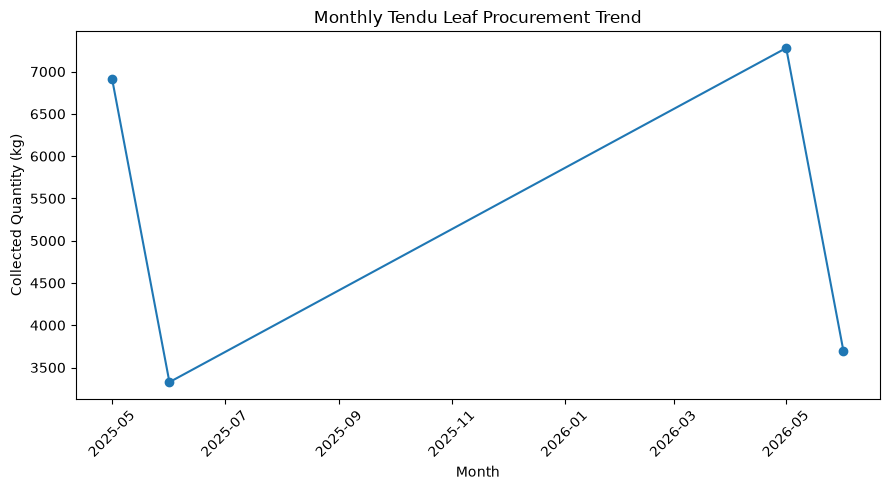

In [49]:
# Chart 1: Monthly procurement trend

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_procurement["collection_date"],
    monthly_procurement["collected_quantity_kg"],
    marker="o"
)

plt.title("Monthly Tendu Leaf Procurement Trend")
plt.xlabel("Month")
plt.ylabel("Collected Quantity (kg)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

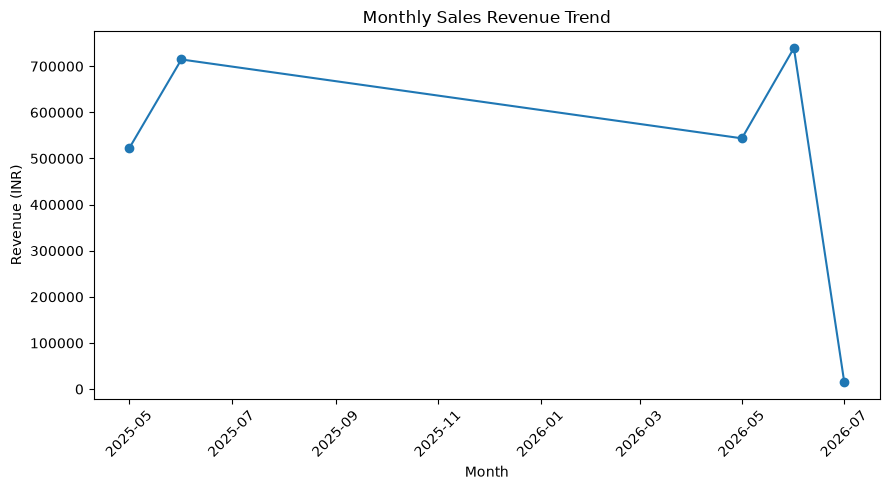

In [50]:
# Chart 2: Monthly revenue trend

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_revenue["sale_date"],
    monthly_revenue["total_sale_value"],
    marker="o"
)

plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

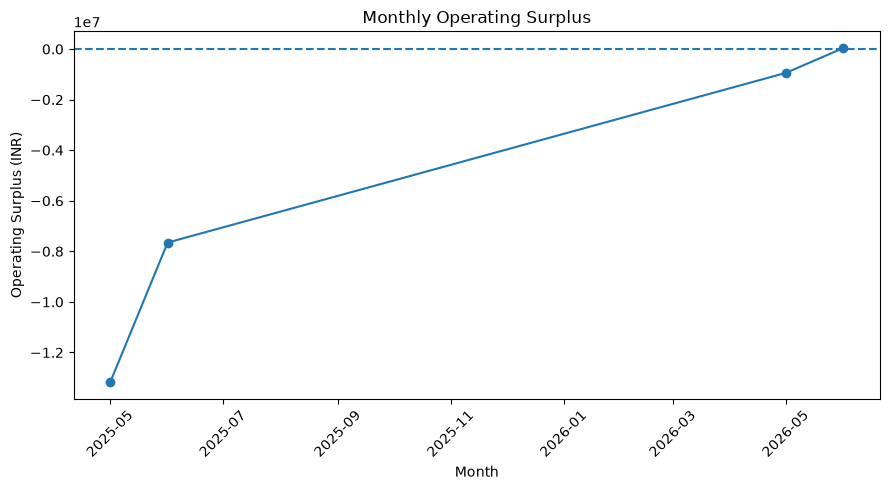

In [51]:
# Chart 3: Monthly operating surplus

plt.figure(figsize=(9, 5))

plt.plot(
    revenue_expense["sale_date"],
    revenue_expense["operating_surplus"],
    marker="o")

plt.axhline(0, linestyle="--")

plt.title("Monthly Operating Surplus")
plt.xlabel("Month")
plt.ylabel("Operating Surplus (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

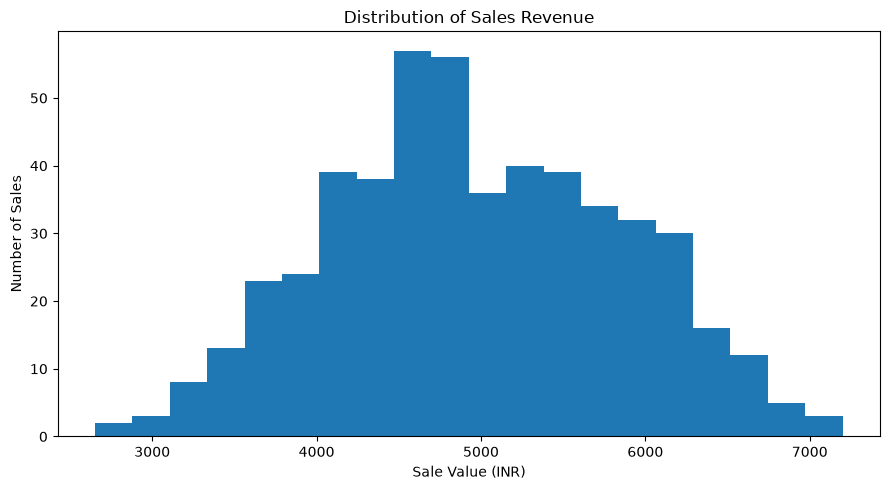

In [52]:
# Chart 4: Distribution of sales revenue

plt.figure(figsize=(9, 5))

plt.hist(
    sales["total_sale_value"],
    bins=20)

plt.title("Distribution of Sales Revenue")
plt.xlabel("Sale Value (INR)")
plt.ylabel("Number of Sales")

plt.tight_layout()
plt.show()

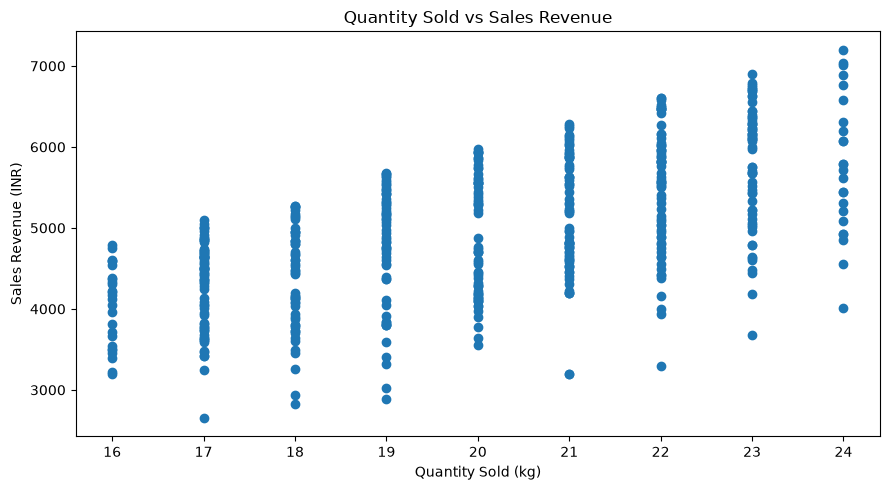

In [53]:
# Chart 5: Quantity sold vs revenue

plt.figure(figsize=(9, 5))

plt.scatter(
    sales["quantity_sold_kg"],
    sales["total_sale_value"])

plt.title("Quantity Sold vs Sales Revenue")
plt.xlabel("Quantity Sold (kg)")
plt.ylabel("Sales Revenue (INR)")

plt.tight_layout()
plt.show()

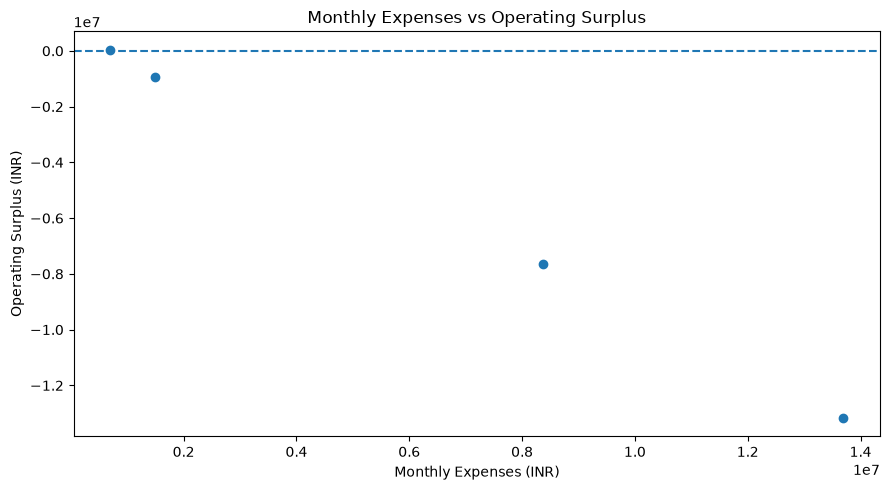

In [54]:
# Chart 6: Expenses vs operating surplus

plt.figure(figsize=(9, 5))

plt.scatter(
    revenue_expense["amount_inr"],
    revenue_expense["operating_surplus"])

plt.axhline(0, linestyle="--")

plt.title("Monthly Expenses vs Operating Surplus")
plt.xlabel("Monthly Expenses (INR)")
plt.ylabel("Operating Surplus (INR)")

plt.tight_layout()
plt.show()

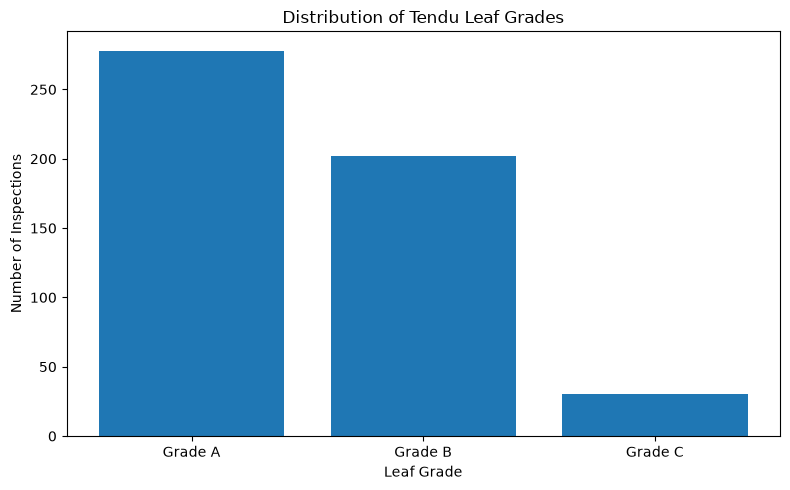

In [55]:
# Chart 7: Leaf grade distribution

grade_counts = quality["leaf_grade"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    grade_counts.index,
    grade_counts.values)

plt.title("Distribution of Tendu Leaf Grades")
plt.xlabel("Leaf Grade")
plt.ylabel("Number of Inspections")

plt.tight_layout()
plt.show()

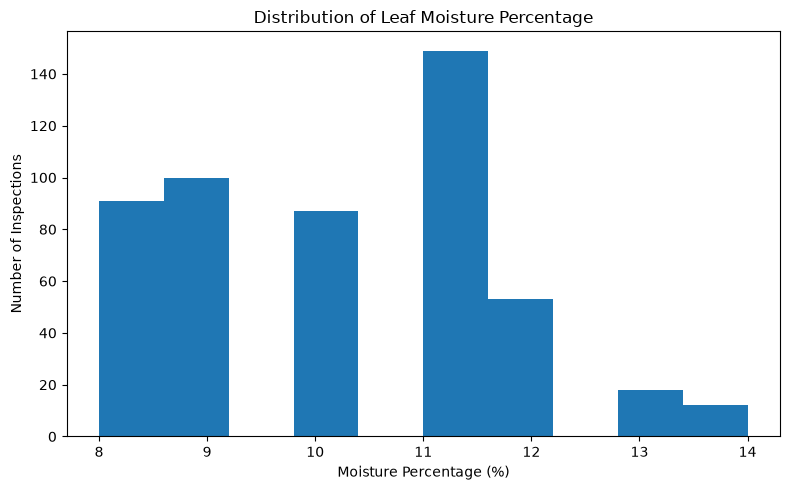

In [56]:
# Chart 8: Moisture percentage distribution

plt.figure(figsize=(8, 5))

plt.hist(
    quality["moisture_percentage"],
    bins=10)

plt.title("Distribution of Leaf Moisture Percentage")
plt.xlabel("Moisture Percentage (%)")
plt.ylabel("Number of Inspections")

plt.tight_layout()
plt.show()

## 7. Business Interpretation

The Python analysis provides insights into procurement, sales, expenses, profitability, and quality patterns within the dataset.

### Key Findings

- Procurement volumes differ noticeably between the observed May and June periods, with May recording higher collection volumes in both years.
- Sales revenue varies across the observed months, with June 2026 recording the highest revenue among the available months.
- Operating surplus varied substantially across the observed period, with June 2026 recording a positive operating surplus while several earlier observed months remained below break-even.
- Sales revenue is moderately positively associated with quantity sold (correlation = 0.626).
- Sales revenue has a stronger positive association with selling price per kg (correlation = 0.759).
- Inspections are concentrated in Grade A and Grade B, while Grade C represents a smaller share of inspections.
- Moisture levels are concentrated within the observed range, with no potential outliers identified using the IQR method.
- No potential sales revenue outliers were identified using the IQR method.

### Business Implications

- Procurement planning can account for differences in collection volumes across the observed periods.
- Revenue performance should be evaluated alongside both sales quantity and selling price.
- Periods with high operating expenses require closer monitoring to protect profitability.
- Grade A and Grade B account for most inspections in the dataset, highlighting the importance of monitoring quality composition across procurement activities.
- Regular monitoring of moisture levels can help maintain consistent leaf quality during storage and handling.

### Analytical Note

The findings describe patterns and associations within the available dataset. They should not be interpreted as evidence of causation without further analysis.

## 8. Prepare Data for Power BI

The Python analysis was used to identify and prepare the datasets most relevant for the final Power BI dashboard.

### Analytical datasets

- Monthly procurement data
- Monthly sales revenue data
- Monthly expense and operating surplus data
- Buyer-level revenue data
- Quality and leaf-grade data
- Sales-level data for detailed analysis

### Power BI preparation

- Dates are stored in usable datetime formats.
- Numerical fields are maintained in appropriate numeric formats.
- Analytical datasets are kept separate where they support specific dashboard views.
- Unnecessary duplication of data is avoided.
- Python is used for statistical analysis and exploratory analysis, while Power BI will be used for interactive reporting and dashboard presentation.

### Python → Power BI Handoff

The final Power BI dashboard will focus on procurement, sales performance, profitability, buyer performance, and quality-related indicators identified during the analysis.

In [65]:
# Review analytical datasets prepared for Power BI

powerbi_datasets = {
    "Monthly Procurement": monthly_procurement,
    "Monthly Revenue & Expenses": monthly_financials,
    "Buyer Revenue": buyer_revenue,
    "Quality by Grade": quality_by_grade,
    "Sales Detail": sales}

for name, df in powerbi_datasets.items():
    print(f"{name}: {df.shape}")


Monthly Procurement: (4, 2)
Monthly Revenue & Expenses: (5, 5)
Buyer Revenue: (70, 4)
Quality by Grade: (3, 2)
Sales Detail: (510, 11)
